In [202]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [203]:
df= pd.read_csv("loan_data.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [204]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

In [205]:
if "Applicant_ID" in df.columns:
	df.drop(columns="Applicant_ID", inplace=True)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    950 non-null    float64
 1   Coapplicant_Income  950 non-null    float64
 2   Employment_Status   950 non-null    str    
 3   Age                 950 non-null    float64
 4   Marital_Status      950 non-null    str    
 5   Dependents          950 non-null    float64
 6   Credit_Score        950 non-null    float64
 7   Existing_Loans      950 non-null    float64
 8   DTI_Ratio           950 non-null    float64
 9   Savings             950 non-null    float64
 10  Collateral_Value    950 non-null    float64
 11  Loan_Amount         950 non-null    float64
 12  Loan_Term           950 non-null    float64
 13  Loan_Purpose        950 non-null    str    
 14  Property_Area       950 non-null    str    
 15  Education_Level     950 non-null    str    
 16  Gender            

In [206]:
df[df.isnull().any(axis=1)].shape
df.isnull().sum()

Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [207]:
for col in df.columns:
    if df[col].dtype == "float64":
        df[col] = df[col].fillna(df[col].median())
    elif df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])

In [208]:
df.isnull().sum()

Applicant_Income       0
Coapplicant_Income     0
Employment_Status     50
Age                    0
Marital_Status        50
Dependents             0
Credit_Score           0
Existing_Loans         0
DTI_Ratio              0
Savings                0
Collateral_Value       0
Loan_Amount            0
Loan_Term              0
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [209]:
for col in df.select_dtypes(include=['object']).columns:
    if col != "Loan_Approved":
        df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\utkar\AppData\Local\Temp\ipykernel_21288\3331779427.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [210]:
for col in df.columns:
    if col == "Loan_Approved":
        df = df[df[col].notna()]

In [211]:
df.isnull().sum()
df.info()

<class 'pandas.DataFrame'>
Index: 950 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    950 non-null    float64
 1   Coapplicant_Income  950 non-null    float64
 2   Employment_Status   950 non-null    str    
 3   Age                 950 non-null    float64
 4   Marital_Status      950 non-null    str    
 5   Dependents          950 non-null    float64
 6   Credit_Score        950 non-null    float64
 7   Existing_Loans      950 non-null    float64
 8   DTI_Ratio           950 non-null    float64
 9   Savings             950 non-null    float64
 10  Collateral_Value    950 non-null    float64
 11  Loan_Amount         950 non-null    float64
 12  Loan_Term           950 non-null    float64
 13  Loan_Purpose        950 non-null    str    
 14  Property_Area       950 non-null    str    
 15  Education_Level     950 non-null    str    
 16  Gender              950 

In [212]:
for val in df["Loan_Approved"].unique():
    print(repr(val))


'No'
'Yes'


In [213]:
df["Loan_Approved"]= df["Loan_Approved"].map({"Yes":1, "No":0})
df["Loan_Approved"].unique()

array([0, 1])

In [214]:
df.head(10)
df["Loan_Approved"].value_counts()

Loan_Approved
0    652
1    298
Name: count, dtype: int64

In [215]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Applicant_Income', ylabel='Loan_Amount'>

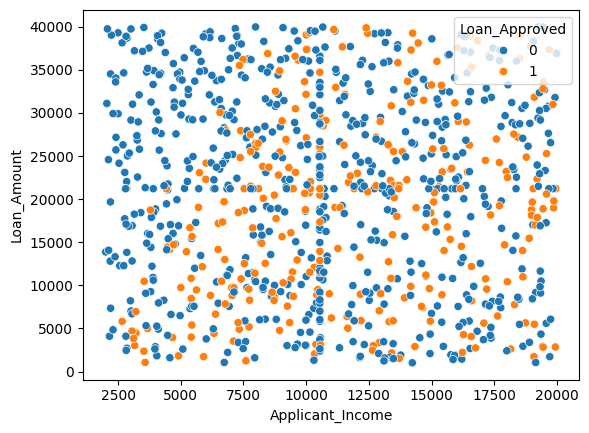

In [216]:
sns.scatterplot(x="Applicant_Income", y="Loan_Amount", hue="Loan_Approved", data=df)

([<matplotlib.axis.XTick at 0x228f8540f50>,
 [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

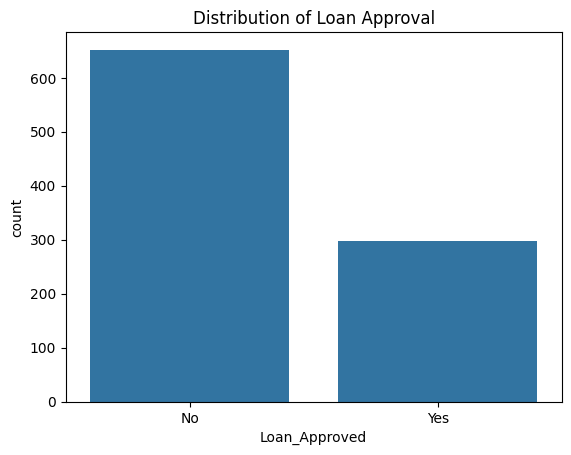

In [217]:
sns.countplot(x="Loan_Approved", data=df)
plt.title("Distribution of Loan Approval")
plt.xticks(ticks=[0, 1], labels=["No", "Yes"])

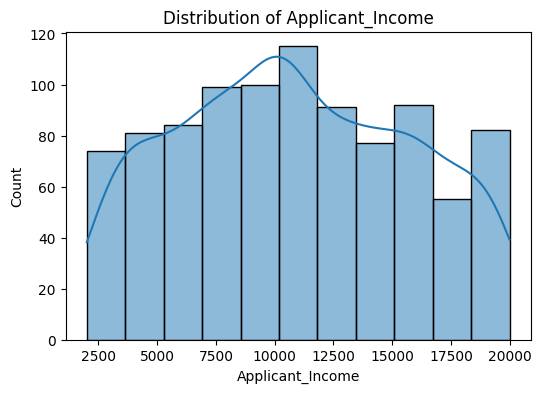

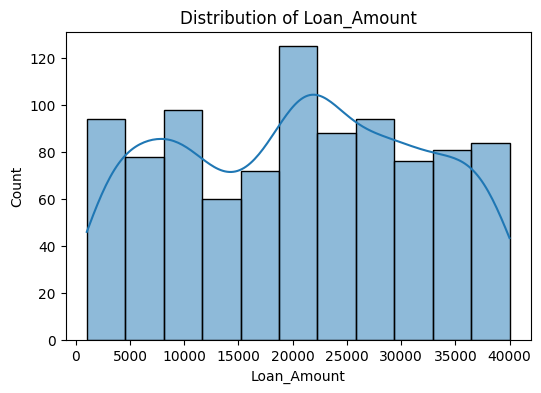

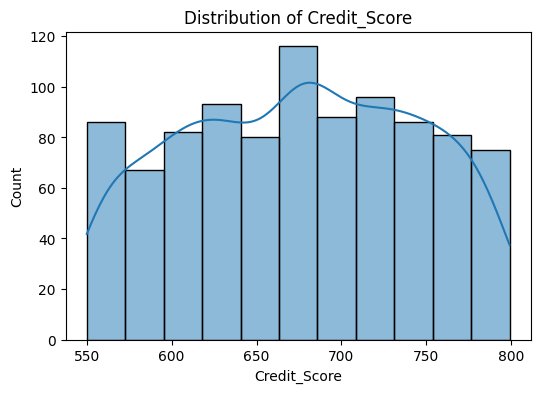

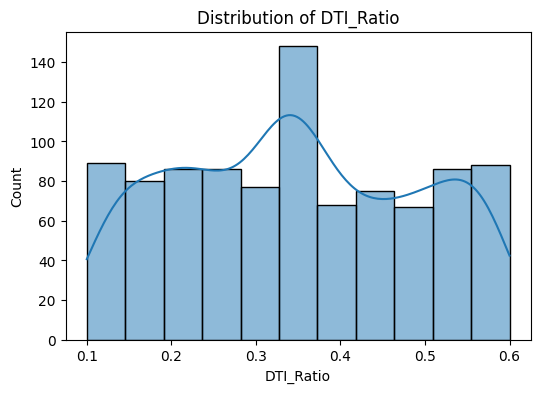

In [218]:
features = ["Applicant_Income", "Loan_Amount", "Credit_Score", "DTI_Ratio"]

for col in features:
    fig, ax= plt.subplots(figsize=(6,4))
    sns.histplot(df[col], kde=True, ax=ax)
    plt.title(f"Distribution of {col}")
    plt.show()

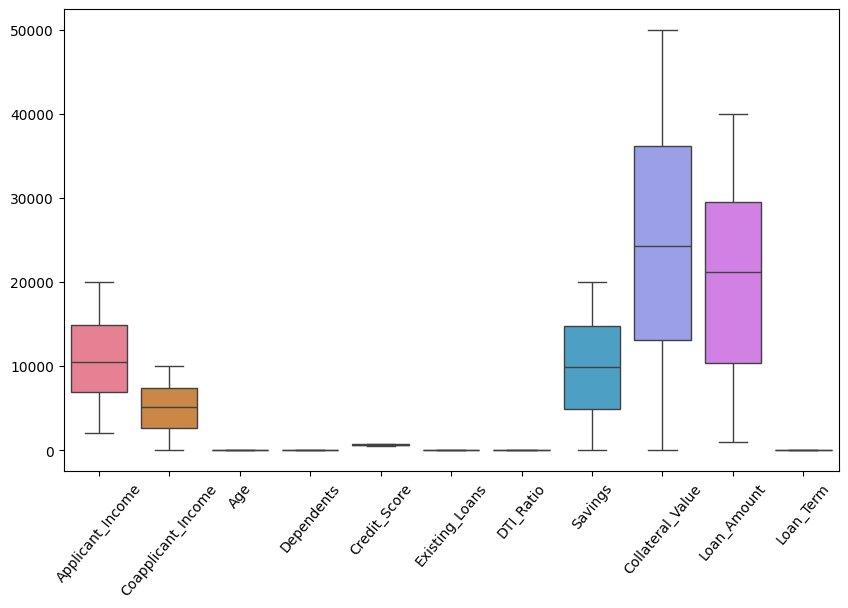

In [219]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.select_dtypes(include=['float64']))
plt.xticks(rotation=50)
plt.show()

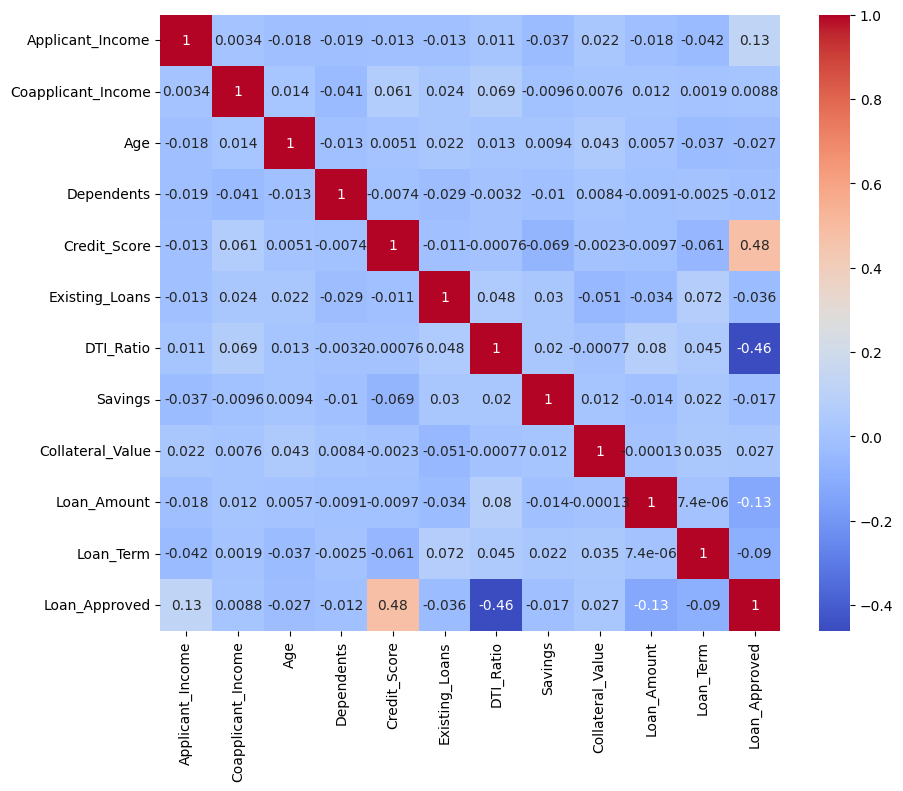

In [220]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [221]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [222]:
df["Loan_Approved"].nunique()

2

In [223]:
X= df.drop(columns=["Loan_Amount","Loan_Approved"])
y= df["Loan_Amount"]
X= pd.get_dummies(X, drop_first= True)

In [224]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Term,...,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Education_Level_Not Graduate,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
985,10705.0,7898.0,33.0,1.0,704.0,4.0,0.55,569.0,2654.0,84.0,...,True,False,False,False,False,False,False,False,True,False
299,10173.0,2808.0,25.0,0.0,745.0,3.0,0.22,18055.0,3838.0,24.0,...,False,False,False,True,False,True,False,False,False,False
571,7997.0,3432.0,53.0,1.0,750.0,4.0,0.52,9880.5,31736.0,36.0,...,False,False,False,True,False,True,False,False,True,False
282,14249.0,4311.0,24.0,2.0,785.0,4.0,0.38,2284.0,26754.0,48.0,...,True,False,False,True,False,False,False,True,False,False
112,3059.0,1750.0,49.0,0.0,770.0,4.0,0.13,15456.0,5067.0,72.0,...,False,False,False,False,False,True,True,False,False,False


In [225]:
model= LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [226]:
y_pred= model.predict(X_test)
y_pred

array([19484.04193557, 20157.7100629 , 20630.1338257 , 22957.26768793,
       20353.09035164, 22572.02906982, 14552.78850452, 19502.63839286,
       18106.2772436 , 19819.29347746, 16783.84931493, 21397.14707616,
       22669.81982804, 18828.33472809, 21382.3670155 , 21460.53451187,
       22147.70152987, 23577.21610823, 17257.67061667, 14826.86644641,
       19372.37253825, 18041.28898638, 20487.108631  , 17242.45054927,
       15034.67914522, 19146.46265222, 19683.64723352, 20469.48097076,
       25859.33921306, 22177.91944055, 22021.63043387, 21968.6869887 ,
       23729.05224502, 22902.94314701, 14715.19800435, 22525.06148077,
       23697.99798699, 21387.39723077, 19842.59015655, 17585.96481006,
       20555.80105523, 23402.40078629, 20668.63719128, 21119.5461061 ,
       18885.43020932, 17564.94251649, 21554.46153588, 21244.01606868,
       19056.25112807, 20377.50369461, 23649.63591556, 18514.06868293,
       16840.33340274, 19151.78054238, 15053.04984896, 19230.01528365,
      

In [227]:
y_test

205    20095.0
978    23705.0
728    22246.0
839    34800.0
919    23733.0
        ...   
628    15817.0
35     28794.0
33     17863.0
746    36892.0
307    23320.0
Name: Loan_Amount, Length: 190, dtype: float64

In [228]:
r2= r2_score(y_test, y_pred)
r2
mse= mean_squared_error(y_test, y_pred)
mse

124413579.7185323

50 is [124406670.4326157, 124344906.86837596, 124399770.4789747, 124379126.59718353, 124413510.57940032, 124413234.03246713, 124412888.3695162, 124410123.90071706, 124277167.99036923, 123768867.22912957, 123217520.22526152, 122759539.20366749, 122943568.85270129, 122589716.20137912]


<Axes: >

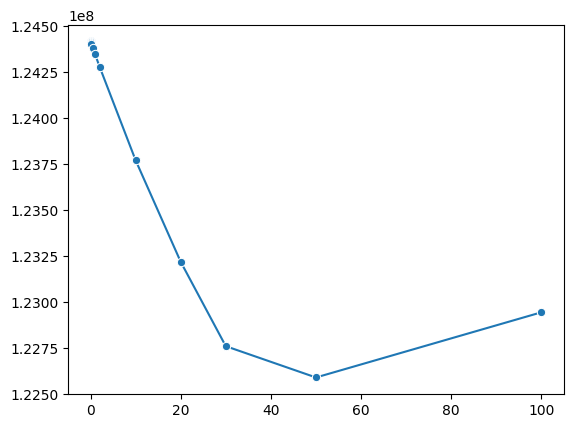

In [229]:
from sklearn import linear_model
alpha=[ 0.1, 1.0,0.2,0.5,0.001,0.005, 0.01, 0.05,2,10,20,30,100,50]
mse_list=[]
for a in alpha:
    lasso=linear_model.Lasso(alpha=a)
    lasso.fit(X_train, y_train)
    y_pred=lasso.predict(X_test)
    mse=mean_squared_error(y_test, y_pred)
    mse_list.append(mse)
print(f"{a} is {mse_list}")
sns.lineplot(x=alpha, y= mse_list, marker="o")

In [230]:
from sklearn.linear_model import LassoCV
lasso_cv= LassoCV(alphas=alpha, cv=5)
lasso_cv.fit(X_train, y_train)
print(f"Best alpha: {lasso_cv.alpha_}")

y_pred_lasso= lasso_cv.predict(X_test)
mse= mean_squared_error(y_test, y_pred_lasso)
print(f"MSE for LassoCV: {mse}")

Best alpha: 100.0
MSE for LassoCV: 122943568.85270129


In [232]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
X = df.drop("Loan_Approved", axis=1)
y= df["Loan_Approved"]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

In [234]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train= scaler. fit_transform(X_train)
X_test= scaler.transform(X_test)

In [239]:
model= LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [240]:
y_pred= model.predict(X_test)
print(f"Accuracy Score:{accuracy_score(y_test, y_pred)}")
print(f"Precision Score:{precision_score(y_test, y_pred)}")
print(f"Recall Score:{recall_score(y_test, y_pred)}")
print(f"F1 Score:{f1_score(y_test, y_pred)}")

Accuracy Score:0.9052631578947369
Precision Score:0.8307692307692308
Recall Score:0.8852459016393442
F1 Score:0.8571428571428571


In [241]:
from sklearn.metrics import confusion_matrix, classification_report
cm=confusion_matrix(y_test, y_pred)
cm

array([[118,  11],
       [  7,  54]])

In [242]:
report= classification_report(y_test, y_pred)
report

'              precision    recall  f1-score   support\n\n           0       0.94      0.91      0.93       129\n           1       0.83      0.89      0.86        61\n\n    accuracy                           0.91       190\n   macro avg       0.89      0.90      0.89       190\nweighted avg       0.91      0.91      0.91       190\n'

In [243]:
print("recall:", recall_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred))

recall: 0.8852459016393442
f1_score: 0.8571428571428571


In [244]:
from sklearn.neighbors import KNeighborsClassifier
knn= KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [247]:
y_pred= knn.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")

Accuracy: 0.7947368421052632
Precision: 0.75


In [248]:
knn= KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred= knn.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")

Accuracy: 0.7947368421052632
Precision: 0.75


In [249]:
knn= KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
y_pred= knn.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")

Accuracy: 0.7736842105263158
Precision: 0.7368421052631579


In [250]:
knn= KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
y_pred= knn.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")

Accuracy: 0.7684210526315789
Precision: 0.7297297297297297


In [251]:
from sklearn.model_selection import GridSearchCV
param_grid= {"n_neighbors": [3,5,7,9,11]}
grid_search= GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [253]:
y_pred= grid_search.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [254]:
print(grid_search.best_params_)

{'n_neighbors': 11}


In [256]:
res= pd.DataFrame(grid_search.cv_results_)
print(res[["param_n_neighbors", "mean_test_score"]])

   param_n_neighbors  mean_test_score
0                  3         0.717105
1                  5         0.743421
2                  7         0.744737
3                  9         0.761842
4                 11         0.761842


In [258]:
from sklearn.naive_bayes import GaussianNB
gnb= GaussianNB()
gnb.fit(X_train, y_train)
y_pred= gnb.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [259]:
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("precision_score:", precision_score(y_test, y_pred))
print("recall_score:", recall_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred))

accuracy_score: 0.8842105263157894
precision_score: 0.8979591836734694
recall_score: 0.7213114754098361
f1_score: 0.8
